# Data Cleaning and Preparation
- Handling Missing Data
- Duplicate data
- Wrong Data Types
- Outlier Values identify and removal

## Handling Missing Data
- Drop the data
- Fill the missing data


In [1]:
import pandas as pd

In [2]:
data = pd.read_excel('employee.xlsx')

In [3]:
data.shape

(26, 6)

In [4]:
data.columns

Index(['Serial', 'Emp_ID', 'Designation', 'Department', 'Age', 'Salary'], dtype='str')

In [5]:
data.index

RangeIndex(start=0, stop=26, step=1)

In [6]:
data.head()

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
2,2,1203,Officer,HR,28.0,NaN
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0


In [7]:
data.tail()

,Serial,Emp_ID,Designation,Department,Age,Salary
21,21,3214,Accountant,Account,49.0,123000.0
22,22,2156,Engineer,Production,45.0,89000.0
23,23,1098,Officer,IT,25.0,100000.0
24,24,2156,Engineer,Production,45.0,89000.0
25,25,2123,Office Boy,Accounts,27.0,45000.0


In [8]:
data.sample(5)

,Serial,Emp_ID,Designation,Department,Age,Salary
1,1,1107,Officer,IT,30.0,80000.0
11,11,3214,Accountant,Account,49.0,123000.0
12,12,2156,Engineer,Production,45.0,89000.0
0,0,1101,Manager,Accounts,50.0,200000.0
14,14,2912,Officer,IT,31.0,90000.0


In [9]:
data.describe()

,Serial,Emp_ID,Age,Salary
count,26.000000,26.000000,25.000000,23.000000
mean,12.500000,2166.692308,35.000000,94173.913043
std,7.648529,1463.539074,9.746794,33714.917354
min,0.000000,1001.000000,23.000000,45000.000000
25%,6.250000,1108.000000,27.000000,84500.000000
50%,12.500000,2123.000000,30.000000,90000.000000
75%,18.750000,2156.000000,45.000000,105000.000000
max,25.000000,6543.000000,50.000000,200000.000000


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Serial       26 non-null     int64  
 1   Emp_ID       26 non-null     int64  
 2   Designation  26 non-null     str    
 3   Department   24 non-null     str    
 4   Age          25 non-null     float64
 5   Salary       23 non-null     float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.3 KB


In [11]:
data.isna().sum()
#data.isnull()

Serial         0
Emp_ID         0
Designation    0
Department     2
Age            1
Salary         3
dtype: int64

In [12]:
data.isnull().sum()

Serial         0
Emp_ID         0
Designation    0
Department     2
Age            1
Salary         3
dtype: int64

In [13]:
data.notna().sum()


Serial         26
Emp_ID         26
Designation    26
Department     24
Age            25
Salary         23
dtype: int64

In [14]:
data.notnull().sum()

Serial         26
Emp_ID         26
Designation    26
Department     24
Age            25
Salary         23
dtype: int64

###dropping data

In [15]:
data.dropna(axis=0)  # rows

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0
7,7,1001,Officer,IT,25.0,75000.0
9,9,2156,Engineer,Production,45.0,89000.0
10,10,6543,Officer,Production,29.0,100000.0
11,11,3214,Accountant,Account,49.0,123000.0
12,12,2156,Engineer,Production,45.0,89000.0
13,13,1098,Officer,IT,25.0,100000.0


In [16]:
data.dropna(axis=1)  # column

,Serial,Emp_ID,Designation
0,0,1101,Manager
1,1,1107,Officer
2,2,1203,Officer
3,3,1005,Manager
4,4,2123,Office Boy
5,5,2451,Accountant
6,6,1111,Accountant
7,7,1001,Officer
8,8,1234,Manager
9,9,2156,Engineer


In [17]:
data.dropna(axis=1, how='all')

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
2,2,1203,Officer,HR,28.0,NaN
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0
5,5,2451,Accountant,NaN,34.0,100000.0
6,6,1111,Accountant,Accounts,NaN,110000.0
7,7,1001,Officer,IT,25.0,75000.0
8,8,1234,Manager,IT,23.0,NaN
9,9,2156,Engineer,Production,45.0,89000.0


In [18]:
data.dropna(axis=1, thresh=int(data.shape[0]*0.90))

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
2,2,1203,Officer,HR,28.0,NaN
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0
5,5,2451,Accountant,NaN,34.0,100000.0
6,6,1111,Accountant,Accounts,NaN,110000.0
7,7,1001,Officer,IT,25.0,75000.0
8,8,1234,Manager,IT,23.0,NaN
9,9,2156,Engineer,Production,45.0,89000.0


In [19]:
data.dropna(axis=0, thresh=int(data.shape[1]*0.90))

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
2,2,1203,Officer,HR,28.0,NaN
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0
5,5,2451,Accountant,NaN,34.0,100000.0
6,6,1111,Accountant,Accounts,NaN,110000.0
7,7,1001,Officer,IT,25.0,75000.0
8,8,1234,Manager,IT,23.0,NaN
9,9,2156,Engineer,Production,45.0,89000.0


## Filling the missing data

In [20]:
data.fillna(1000)

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50.0,200000.0
1,1,1107,Officer,IT,30.0,80000.0
2,2,1203,Officer,HR,28.0,1000.0
3,3,1005,Manager,HR,45.0,120000.0
4,4,2123,Office Boy,Accounts,27.0,45000.0
5,5,2451,Accountant,1000,34.0,100000.0
6,6,1111,Accountant,Accounts,1000.0,110000.0
7,7,1001,Officer,IT,25.0,75000.0
8,8,1234,Manager,IT,23.0,1000.0
9,9,2156,Engineer,Production,45.0,89000.0


In [21]:
data.Age.fillna(data.Age.mean())

0     50.0
1     30.0
2     28.0
3     45.0
4     27.0
5     34.0
6     35.0
7     25.0
8     23.0
9     45.0
10    29.0
11    49.0
12    45.0
13    25.0
14    31.0
15    25.0
16    45.0
17    27.0
18    45.0
19    27.0
20    29.0
21    49.0
22    45.0
23    25.0
24    45.0
25    27.0
Name: Age, dtype: float64

In [22]:
data.Department.fillna((data.Department.mode()[0]))

0       Accounts
1             IT
2             HR
3             HR
4       Accounts
5     Production
6       Accounts
7             IT
8             IT
9     Production
10    Production
11       Account
12    Production
13            IT
14            IT
15    Production
16    Production
17      Accounts
18            HR
19      Accounts
20    Production
21       Account
22    Production
23            IT
24    Production
25      Accounts
Name: Department, dtype: str

In [23]:
data.Salary.fillna(data.Salary.median())

0     200000.0
1      80000.0
2      90000.0
3     120000.0
4      45000.0
5     100000.0
6     110000.0
7      75000.0
8      90000.0
9      89000.0
10    100000.0
11    123000.0
12     89000.0
13    100000.0
14     90000.0
15     90000.0
16     89000.0
17     45000.0
18    120000.0
19     45000.0
20    100000.0
21    123000.0
22     89000.0
23    100000.0
24     89000.0
25     45000.0
Name: Salary, dtype: float64

In [24]:
data = data.fillna({'Age':data.Age.mean(), 'Department':data.Department.mode()[0], 'Salary':data.Age.median()})

In [26]:
import seaborn as sns

<Axes: ylabel='Salary'>

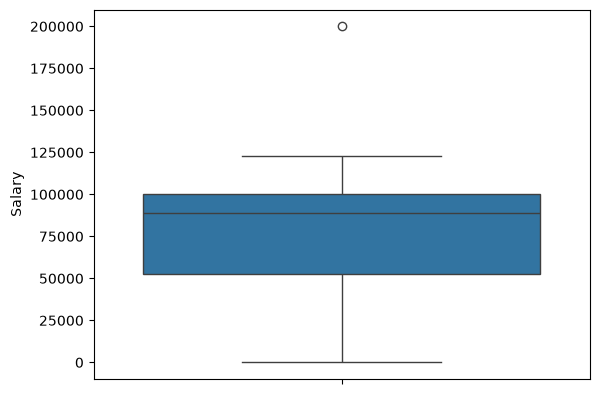

In [27]:
sns.boxplot(data.Salary)

In [28]:
data.describe()

,Serial,Emp_ID,Age,Salary
count,26.000000,26.000000,26.000000,26.000000
mean,12.500000,2166.692308,35.000000,83311.153846
std,7.648529,1463.539074,9.549869,44058.391013
min,0.000000,1001.000000,23.000000,30.000000
25%,6.250000,1108.000000,27.000000,52500.000000
50%,12.500000,2123.000000,30.500000,89000.000000
75%,18.750000,2156.000000,45.000000,100000.000000
max,25.000000,6543.000000,50.000000,200000.000000


In [30]:
data.to_excel('emp.xlsx', index=False)